In [45]:
import numpy as np
import pandas as pd
import sweetviz as sv

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



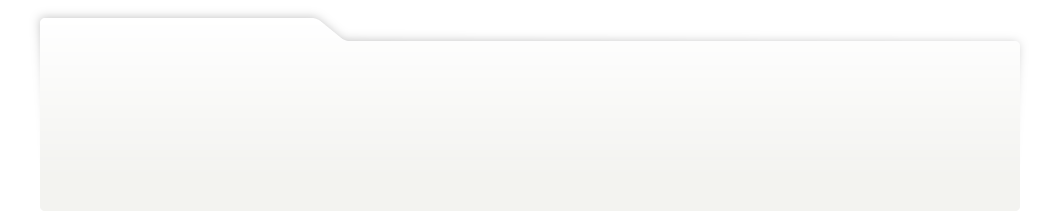
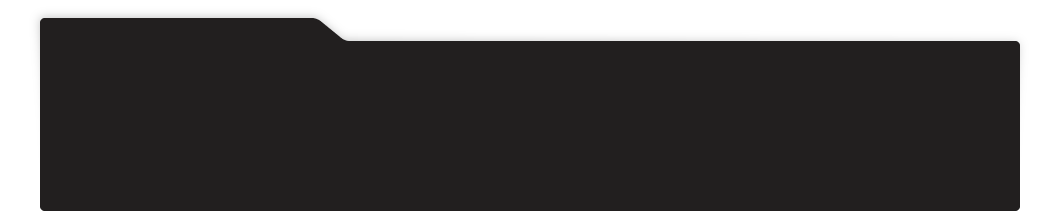
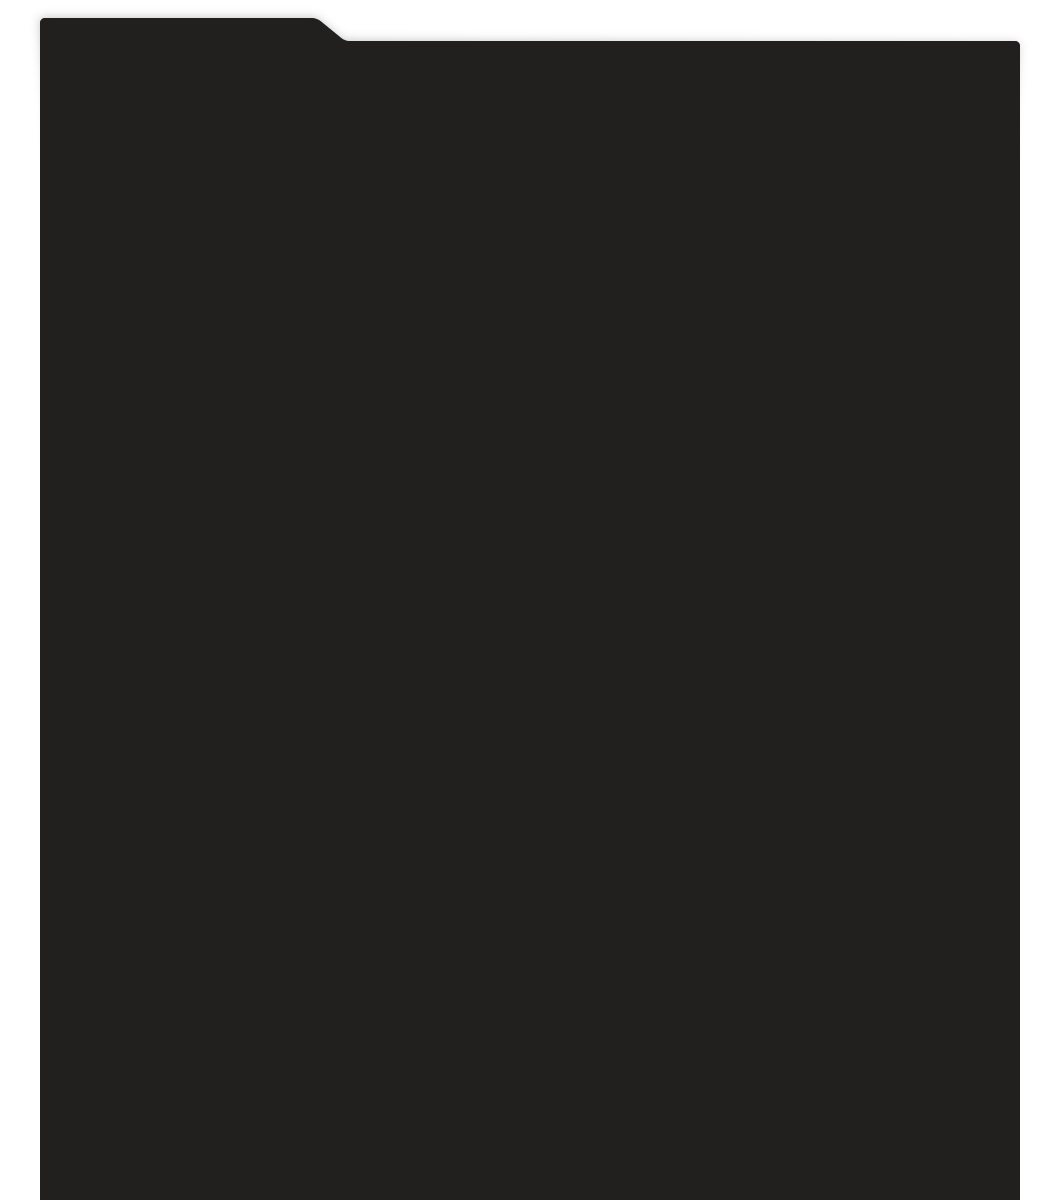
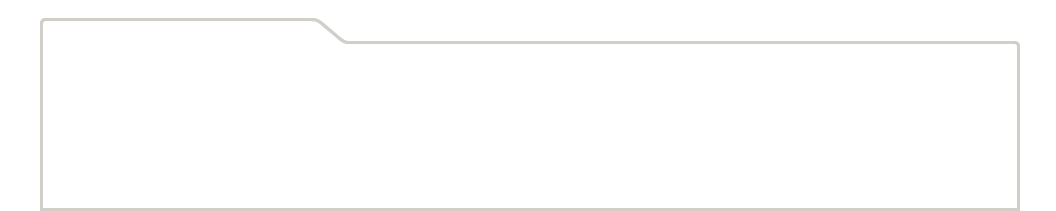
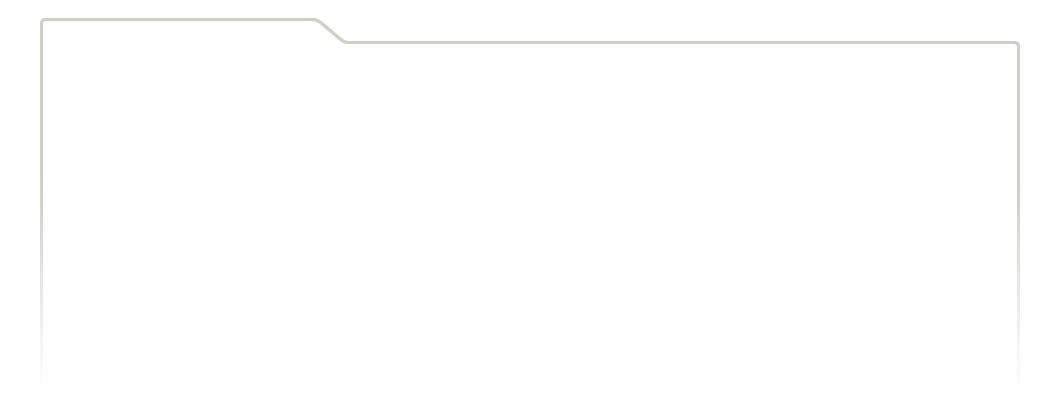
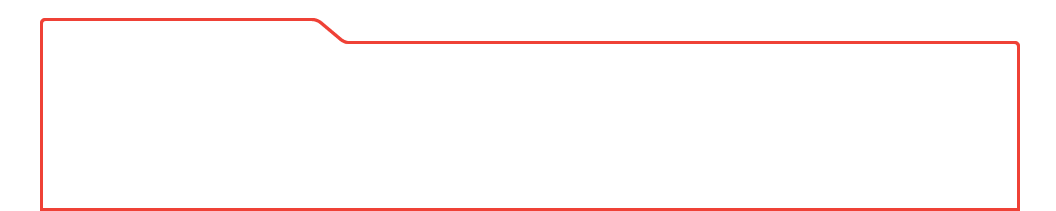
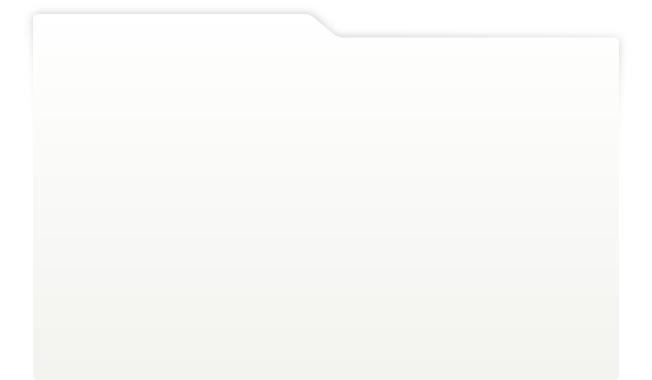
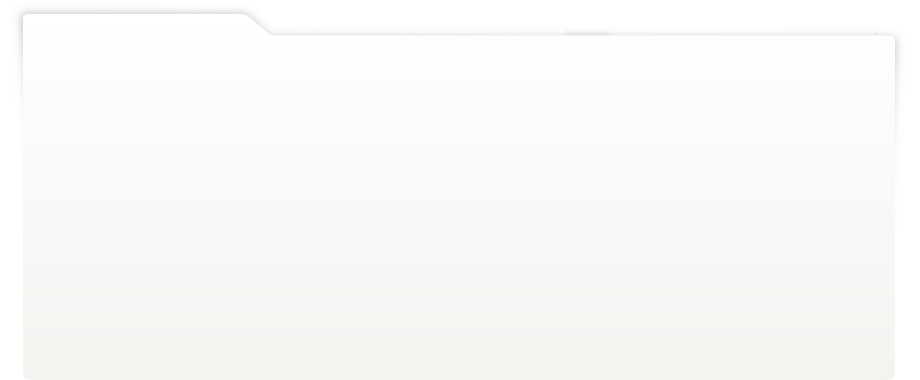
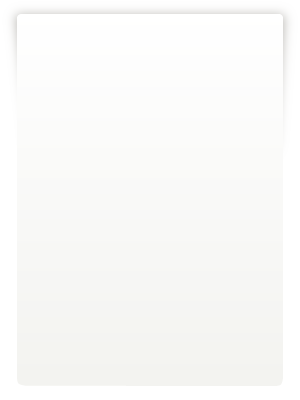
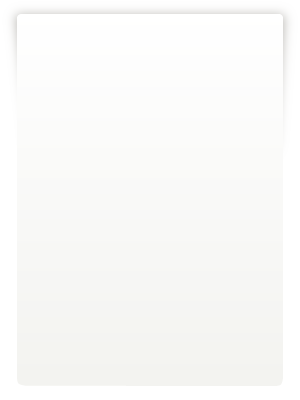
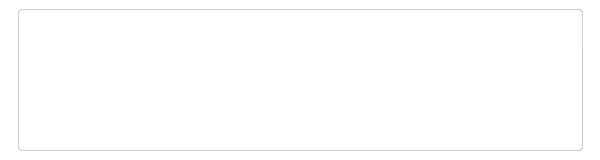
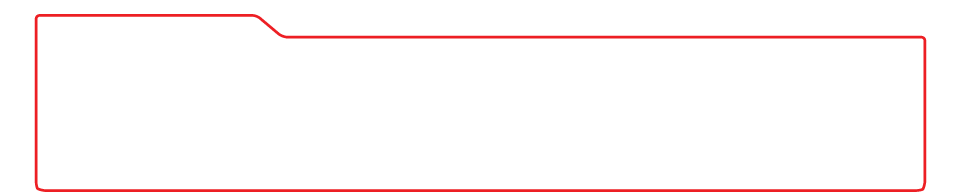
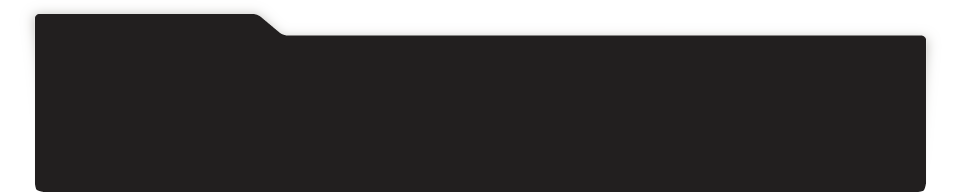
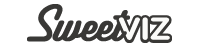
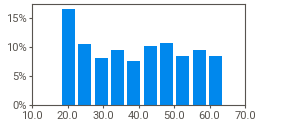
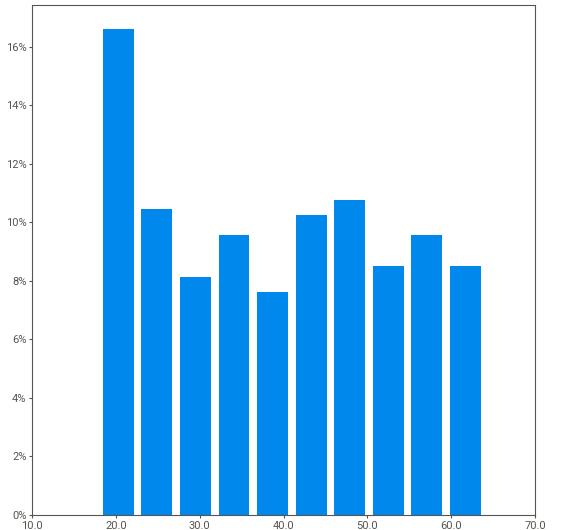
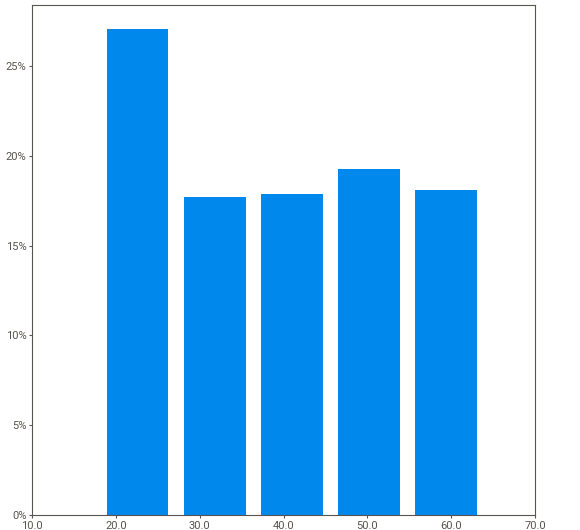
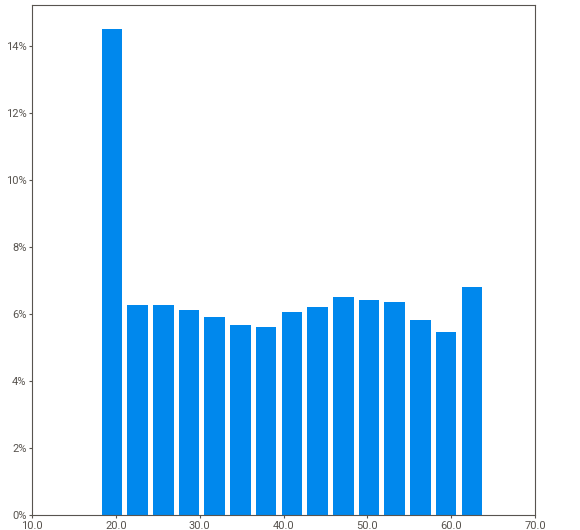
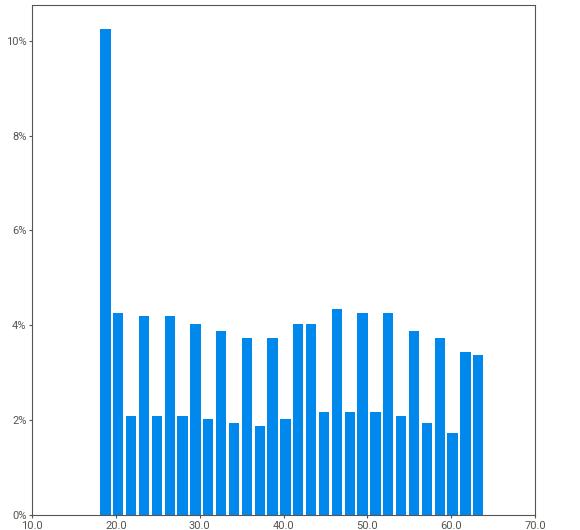
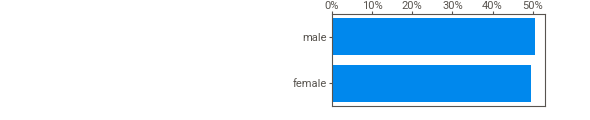
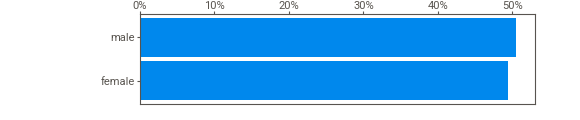
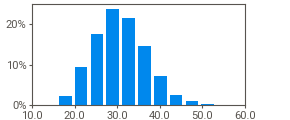
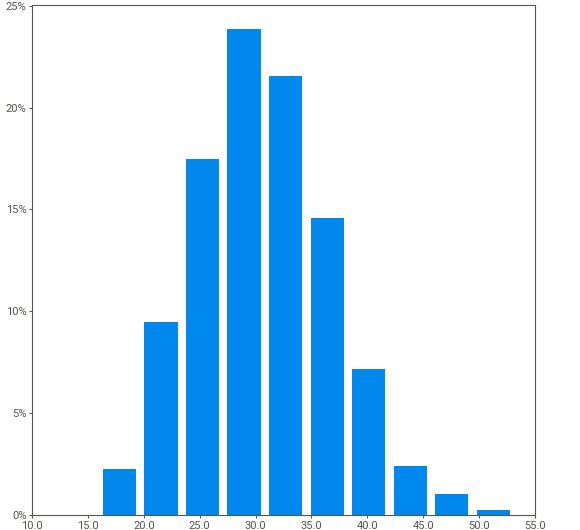
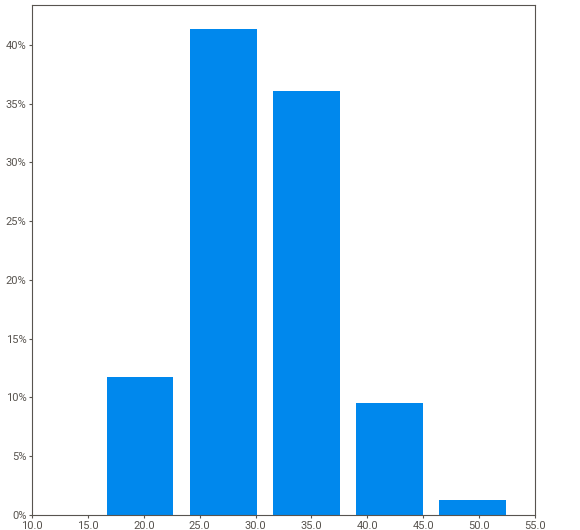
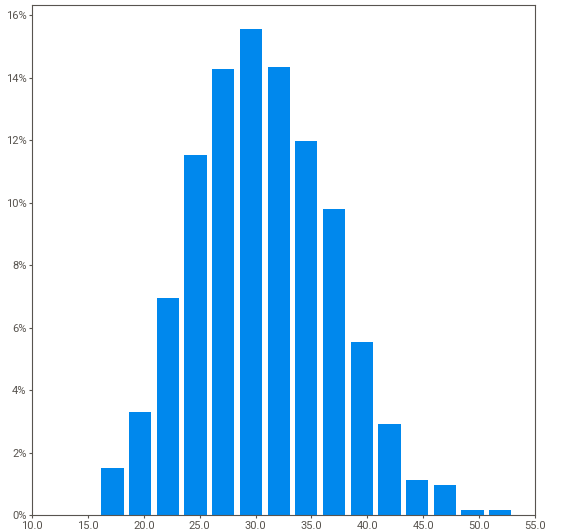
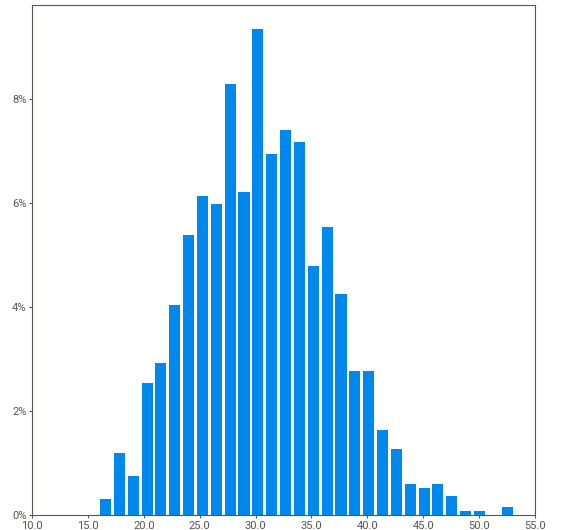
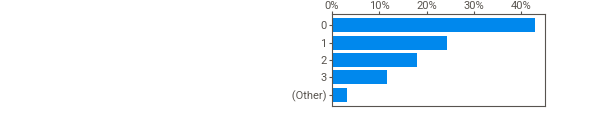
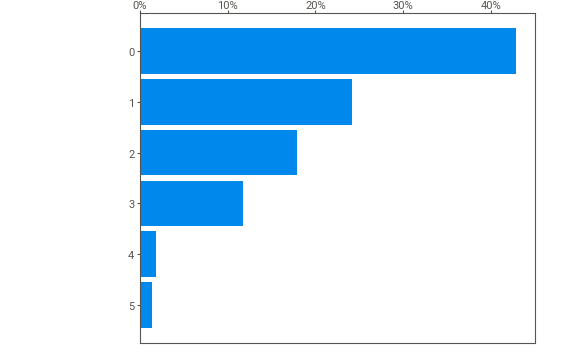
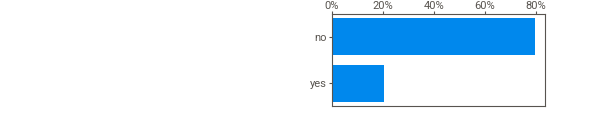
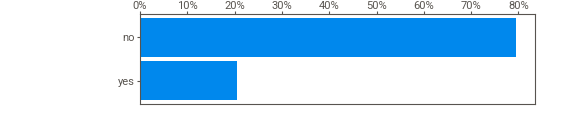
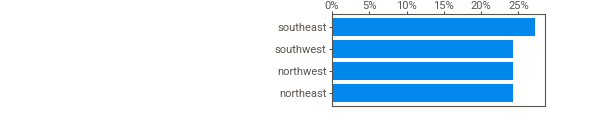
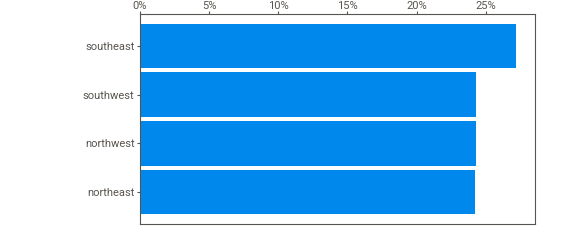
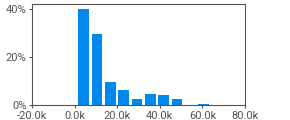
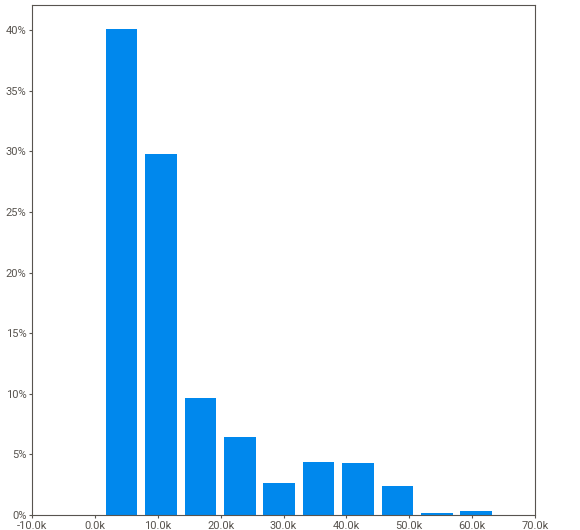
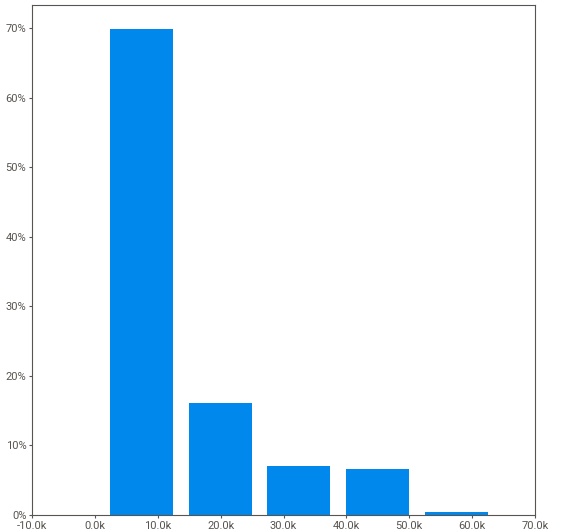
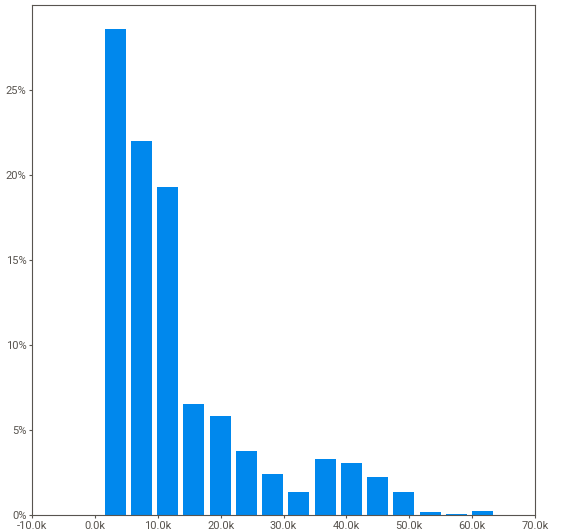
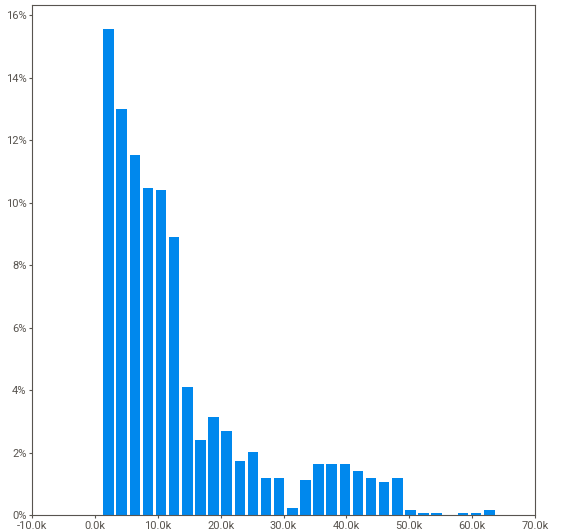
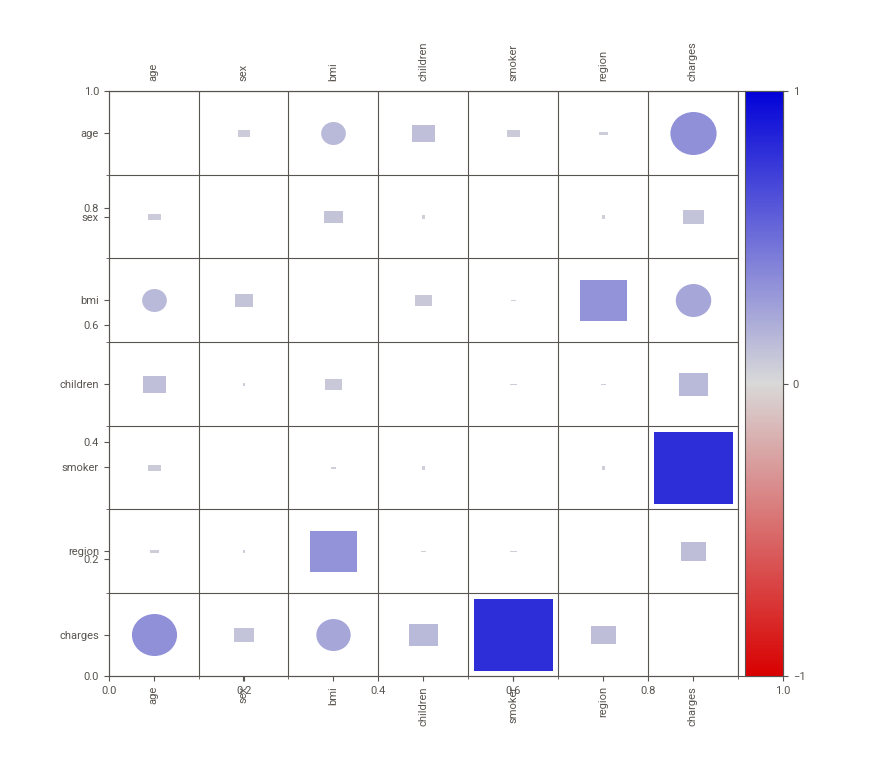
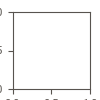

In [60]:
report = sv.analyze(df)
report.show_notebook();

In [48]:
# dummify cats
df_encoded = pd.get_dummies(df, drop_first=True).astype(int)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [49]:
X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]

# scale data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
# get training data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Base Model Performance

**Linear Regression**
- average prediction distance from true value is around \$5,800.
- good $r^2$

**Random Forest**
- average prediction distance from true value is around \$4,800.
- better $r^2$


Overall, the base random forest model performs better than the base linear regression. There is no indication of over/underfitting in either model, but the random forest finds a better fit with less error.

In [51]:
# linear regression base
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

(np.sqrt(mse_lr), r2_lr)

(np.float64(5793.655127404499), 0.7837888448800692)

In [52]:
# random forest base
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

(np.sqrt(mse_rf), r2_rf)

(np.float64(4705.308120399603), 0.8573903371978231)

In [53]:
# cv with baseline
cross_val_score(lr, X_train, y_train, cv=5).mean()

np.float64(0.7330691648735671)

In [54]:
cross_val_score(rf, X_train, y_train, cv=5).mean()

np.float64(0.823941765904957)

In [55]:
# grid search to tune RF
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ['sqrt', 'log2']
}

gscv = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2"
)
gscv.fit(X_train, y_train)

# best hyperparams
gscv.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [56]:
gscv_results = pd.DataFrame(gscv.cv_results_)
gscv_results.sort_values("mean_test_score", ascending=False)[:20][["mean_test_score", "params", "mean_fit_time"]]

,mean_test_score,params,mean_fit_time
14,0.841452,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.081303
15,0.841013,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.164374
13,0.840173,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.186167
22,0.839944,"{'max_depth': 20, 'max_features': 'log2', 'min...",0.082787
23,0.839661,"{'max_depth': 20, 'max_features': 'log2', 'min...",0.162553
7,0.839619,"{'max_depth': None, 'max_features': 'log2', 'm...",0.172042
6,0.838484,"{'max_depth': None, 'max_features': 'log2', 'm...",0.089236
12,0.838370,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.091137
5,0.837069,"{'max_depth': None, 'max_features': 'log2', 'm...",0.206938
4,0.836144,"{'max_depth': None, 'max_features': 'log2', 'm...",0.105113


Choosing from the top 20 best tuned models, I would choose the set of hyperparameters that minimizes the `mean_fit_time` and maximizes the `mean_test_score`. In this particular example, where the difference in fit times is only a few milliseconds, I would choose the combination of params at index 15, which achieves the best score ($r^2$).

In [57]:
pd.Series(gscv_results.iloc[15].params) # this is also the same as gscv.best_estimator_

max_depth              10
max_features         log2
min_samples_split       5
n_estimators          200
dtype: object

## comparing test and train results

the model performs slightly better on the training data, but it seems to generalize pretty well on the testing data. With similar $r^2$, I don't think the model is overfitting/memorizing the training data.

In [58]:
me_train = np.sqrt(cross_val_score(gscv.best_estimator_, X_train, y_train, cv=5, scoring="neg_mean_squared_error").mean() * -1)
r2_train = cross_val_score(gscv.best_estimator_, X_train, y_train, cv=5, scoring="r2").mean()

(me_train, r2_train)

(np.float64(4726.863315042151), np.float64(0.8411673315670025))

In [59]:
me_test = np.sqrt(cross_val_score(gscv.best_estimator_, X_test, y_test, cv=5, scoring="neg_mean_squared_error").mean() * -1)
r2_test = cross_val_score(gscv.best_estimator_, X_test, y_test, cv=5, scoring="r2").mean()

(me_test, r2_test)

(np.float64(5399.8305501213745), np.float64(0.8175873405943388))